<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Output Analysis — Multiple Models

Summer Semester 26

Prof. Dr. Gunther Gust <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

In [1]:
# Imports — run once
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# D3 colour palette
D3_BLUE   = '#1f77b4'
D3_ORANGE = '#ff7f0e'
D3_GREEN  = '#2ca02c'
D3_RED    = '#d62728'
D3_GRAY   = '#7f7f7f'

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[D3_BLUE, D3_ORANGE, D3_GREEN, D3_RED, D3_GRAY])

# Where we are

<img src="images/simulation_study_steps_output.png" style="width:80%; float:center;" />

**Last lecture — Output Analysis (single model)**: how precise is the estimate for *one* system?

**This lecture**: we have several candidate designs — how do we decide *which one is better*, and separate a real difference from random noise?

# Motivation — how many cashiers should the mensa have?

You simulate two mensa layouts:

> **1 cashier:** average wait ≈ **4.9 min**

> **2 cashiers:** average wait ≈ **0.5 min**

The two-cashier layout looks better — but each number came from *one noisy simulation*. Is the difference **real**, or could it be sampling luck?

And once we have *many* candidates (1, 2, 3, 4 cashiers, different service policies, …) — how do we compare them all **without fooling ourselves**?

# Agenda

1. **Comparing two systems** — CI for the difference, statistical vs practical significance
2. **Common Random Numbers (CRN)** — variance reduction for comparisons
3. **Comparing several systems** — the multiplicity problem and Bonferroni
4. **Metamodeling** — replace the simulation by a cheap fitted function
5. **Optimization via simulation** — searching over many designs
6. **Closing** — which method when?

# Our running example — the mensa, with a tunable number of cashiers

Same model as before, but now `num_cashiers` is a design choice. Everything else (arrival rate, service rate) is fixed.

In [2]:
# --- Logger ---
class EventLogger:
    """Records every simulation event as a DataFrame row."""
    def __init__(self, verbose=False):
        self.events = []
        self.verbose = verbose
    def log(self, **kwargs):
        if self.verbose:
            print('  '.join(f'{k}={v}' for k, v in kwargs.items()))
        self.events.append(kwargs)
    def get_df(self):
        return pd.DataFrame(self.events)


# --- Resource class ---
# Note: a DEDICATED random stream for service times (rng_service), separate from
# the arrival stream. This is what makes Common Random Numbers work later:
# changing the service rate then perturbs ONLY service draws, never arrivals.
class Mensa:
    def __init__(self, env, num_cashiers, mean_service, rng_service):
        self.env = env
        self.counter = simpy.Resource(env, capacity=num_cashiers)
        self.mean_service = mean_service
        self.rng_service = rng_service
    def serve(self):
        yield self.env.timeout(self.rng_service.expovariate(1 / self.mean_service))


# --- Entity class ---
class Student:
    def __init__(self, env, name, mensa, logger):
        self.env, self.name, self.mensa, self.logger = env, name, mensa, logger
    def run(self):
        arrive = self.env.now
        with self.mensa.counter.request() as req:
            yield req
            wait = self.env.now - arrive
            self.logger.log(t=round(self.env.now, 2), name=self.name,
                            event='starts service', wait=round(wait, 2))
            yield self.env.process(self.mensa.serve())


# --- Generator function (dedicated arrival stream) ---
def student_generator(env, mensa, logger, mean_inter, rng_arrival):
    i = 0
    while True:
        yield env.timeout(rng_arrival.expovariate(1 / mean_inter))
        env.process(Student(env, f'S{i}', mensa, logger).run())
        i += 1


# --- Run block ---
# Two independent streams, both derived deterministically from `seed`.
# Same seed  →  identical arrival stream AND identical service-uniform stream,
# regardless of the service rate  →  proper synchronization for CRN.
def run_mensa(seed, num_cashiers=1, mean_inter=2.0, mean_service=1.5,
              sim_time=240, verbose=False):
    rng_arrival = random.Random(seed)
    rng_service = random.Random(seed + 10_000_000)
    env = simpy.Environment()
    mensa = Mensa(env, num_cashiers=num_cashiers, mean_service=mean_service,
                  rng_service=rng_service)
    logger = EventLogger(verbose=verbose)
    env.process(student_generator(env, mensa, logger, mean_inter, rng_arrival))
    env.run(until=sim_time)
    df = logger.get_df()
    return df.loc[df['event'] == 'starts service', 'wait'].reset_index(drop=True)


def mean_wait(seed, **kwargs):
    return run_mensa(seed=seed, **kwargs).mean()

# The motivating numbers, with seeds

In [3]:
# One run each — but remember: a single run is one noisy data point
print(f"1 cashier  (seed 1): mean wait = {mean_wait(1, num_cashiers=1):.2f} min")
print(f"2 cashiers (seed 1): mean wait = {mean_wait(1, num_cashiers=2):.2f} min")

1 cashier  (seed 1): mean wait = 1.57 min
2 cashiers (seed 1): mean wait = 0.09 min


# Part 1 — Comparing Two Systems

## The quantity of interest

We have two designs with true performance measures $\theta_1$ and $\theta_2$ (e.g. mean wait with 1 vs 2 cashiers).

We don't want $\theta_1$ or $\theta_2$ in isolation — we want the **difference**:
$$\theta_1 - \theta_2$$

and a confidence interval for it. The CI tells us whether the difference is **real** and **how big** it is.

## How to read a difference-CI

A $100(1-\alpha)\%$ CI for $\theta_1 - \theta_2$ lands in one of three positions:

| CI position | Conclusion |
|---|---|
| entirely **right of 0** | $\theta_1 > \theta_2$ — system 2 is better (lower wait) |
| entirely **left of 0** | $\theta_1 < \theta_2$ — system 1 is better |
| **contains 0** | no strong evidence either way — collect more data |

<br>

<img src="images/oa_difference_ci_positions.png" style="width:70%; float:center;" />

As $R$ grows, the CI shrinks — a difference that "contains 0" today may resolve later.

## Statistical vs practical significance

These are **two different questions** — recall the tolerance-band idea from V&V:

- **Statistically significant**: the CI excludes 0 → the difference is larger than its noise.
- **Practically significant**: the difference is large enough to *matter* (e.g. exceeds a threshold $\varepsilon$ worth acting on).

A difference can be statistically significant but practically irrelevant (a 0.01-min wait reduction, measured very precisely), or practically large but statistically unresolved (a 2-min reduction with a CI that still straddles it).

→ Always report **both** the CI *and* whether the effect clears your practical threshold.

# 🧠 Mentimeter — your turn (Q1)

➡️ Open the Mentimeter and answer the question on screen.

## Independent sampling — equal variances (pooled)

**Goal:** a confidence interval for the difference $\theta_1 - \theta_2$. Run the two systems with **different** seeds → the samples are independent → $\mathrm{Cov}(\bar Y_{\cdot 1}, \bar Y_{\cdot 2}) = 0$.

**Point estimate**
$$\boxed{\,\bar Y_{\cdot 1} - \bar Y_{\cdot 2}\,}$$

**Standard error** (where $S_p$ is the pooled standard deviation — see next slide)
$$\text{s.e.} = S_p\sqrt{\frac{1}{R_1} + \frac{1}{R_2}}$$

**CI estimate**
$$\boxed{\,(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) \;\pm\; t_{\alpha/2,\, R_1 + R_2 - 2}\cdot \text{s.e.}\,}$$

## Where does the standard error come from?

**Step 1 — variance of the difference estimator** (independent → covariance term vanishes):
$$\mathrm{Var}(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) = \frac{\sigma_1^2}{R_1} + \frac{\sigma_2^2}{R_2}$$

**Step 2 — equal-variance assumption** $\sigma_1^2 = \sigma_2^2 = \sigma^2$ pulls out the common $\sigma^2$:
$$\mathrm{Var}(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) = \sigma^2\!\left(\frac{1}{R_1} + \frac{1}{R_2}\right)$$

**Step 3 — standard error** is the square root:
$$\text{s.e.} = \sigma\sqrt{\frac{1}{R_1} + \frac{1}{R_2}}$$

But $\sigma$ is **unknown** — we have to estimate it from the data. Each system gives its own sample variance
$$S_i^2 = \frac{1}{R_i-1}\sum_{r}(Y_{ri}-\bar Y_{\cdot i})^2.$$
How do we turn these two estimates into a single estimate of $\sigma$? → pool them, next.

## Pooling the two sample variances

Under equal variances, both $S_1^2$ and $S_2^2$ estimate the **same** $\sigma^2$. Combine them into one estimate — a weighted average by degrees of freedom — the **pooled variance**:

$$S_p^2 = \frac{(R_1-1)S_1^2 + (R_2-1)S_2^2}{R_1 + R_2 - 2}$$

- weights are the degrees of freedom $(R_i-1)$ → the larger sample counts more
- using *all* the data for one estimate gives more degrees of freedom → tighter CI
- the denominator $R_1+R_2-2$ is exactly the dof used in the $t$-quantile

Plugging $S_p$ for $\sigma$ gives the standard error from the previous slide:
$$\text{s.e.} = S_p\sqrt{\frac{1}{R_1} + \frac{1}{R_2}}$$

*Sanity check:* if $R_1=R_2=R$ and $S_1=S_2=S$, then $S_p = S$ and s.e. $= S\sqrt{2/R}$ — the two-sample version of the single-mean SE.

## Independent sampling — unequal variances

When the two variances differ (often the case — more cashiers changes the *variability* of waits, not just the mean), **don't pool**. Use the unequal-variances construction (also called the **Welch** interval):

**Point estimate**
$$\boxed{\,\bar Y_{\cdot 1} - \bar Y_{\cdot 2}\,}$$

**Standard error**
$$\text{s.e.} = \sqrt{\frac{S_1^2}{R_1} + \frac{S_2^2}{R_2}}$$

**Degrees of freedom** (Welch–Satterthwaite approximation)
$$\nu = \frac{\left(\dfrac{S_1^2}{R_1} + \dfrac{S_2^2}{R_2}\right)^2}{\dfrac{(S_1^2/R_1)^2}{R_1-1} + \dfrac{(S_2^2/R_2)^2}{R_2-1}}$$

**CI estimate**
$$\boxed{\,(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) \pm t_{\alpha/2,\,\nu}\cdot\text{s.e.}\,}$$

$\nu$ is generally **not an integer** — software evaluates the $t$-distribution directly at the fractional $\nu$. Rule of thumb: $R_1, R_2 > 7$ — *per sample*, so that each variance estimator $S_i^2$ is reliable enough for the Welch–Satterthwaite approximation to hold. The unequal-variances CI is the **safe default** — it reduces to the pooled case when variances are equal.

## Mensa: 1 vs 2 cashiers, independent sampling

In [4]:
R1 = R2 = 10
# Independent: different seed blocks for the two systems
waits_1 = np.array([mean_wait(s,            num_cashiers=1) for s in range(1, R1+1)])
waits_2 = np.array([mean_wait(s + 1000,     num_cashiers=2) for s in range(1, R2+1)])

diff = waits_1.mean() - waits_2.mean()
S1, S2 = waits_1.std(ddof=1), waits_2.std(ddof=1)

# Unequal-variances standard error + Welch–Satterthwaite dof
se = np.sqrt(S1**2/R1 + S2**2/R2)
nu_num = (S1**2/R1 + S2**2/R2)**2
nu_den = (S1**2/R1)**2/(R1-1) + (S2**2/R2)**2/(R2-1)
nu = nu_num / nu_den
t_crit = stats.t.ppf(0.975, nu)
H = t_crit * se

print(f"mean wait, 1 cashier : {waits_1.mean():.2f} min   sample variance S1² = {S1**2:.2f}")
print(f"mean wait, 2 cashiers: {waits_2.mean():.2f} min   sample variance S2² = {S2**2:.2f}")
print(f"→ the variances differ by a factor of ~{max(S1**2,S2**2)/min(S1**2,S2**2):.0f}"
      f"  → pooling would be wrong, the unequal-variances CI is the right choice")
print()
print(f"difference theta_1 - theta_2 = {diff:.2f} min")
print(f"Welch–Satterthwaite dof = {nu:.1f},  t_crit = {t_crit:.2f}")
print(f"95% CI for the difference: [{diff-H:.2f}, {diff+H:.2f}] min")
print()
if diff - H > 0:
    print("CI entirely right of 0 → the 2-cashier system is significantly better.")
elif diff + H < 0:
    print("CI entirely left of 0 → the 1-cashier system is significantly better.")
else:
    print("CI contains 0 → no significant difference detected.")

mean wait, 1 cashier : 4.15 min   sample variance S1² = 4.86
mean wait, 2 cashiers: 0.21 min   sample variance S2² = 0.02
→ the variances differ by a factor of ~204  → pooling would be wrong, the unequal-variances CI is the right choice

difference theta_1 - theta_2 = 3.94 min
Welch–Satterthwaite dof = 9.1,  t_crit = 2.26
95% CI for the difference: [2.36, 5.52] min

CI entirely right of 0 → the 2-cashier system is significantly better.


# 🧠 Mentimeter — your turn (Q2)

➡️ Open the Mentimeter and answer the question on screen.

# Part 2 — Common Random Numbers (CRN)



## The idea — a fair, controlled comparison

A system's output mixes **two** sources of variation:

1. the **difference between the systems** — what we want to measure
2. the **input randomness** (arrivals, service) — noise we don't care about

**Key insight:** feed *both* systems the **same realization of the uncertainty** → any output difference must come from the **systems**, not the noise. A noisy comparison becomes a *controlled experiment*.

That is **Common Random Numbers (CRN)**: same random stream for both → induces **positive correlation** → shrinks the variance of the difference (next slide).

## Why it works — straight from the variance rule

Recall the variance-of-a-difference rule (Lecture 9, Part 4):
$$\mathrm{Var}(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) = \mathrm{Var}(\bar Y_{\cdot 1}) + \mathrm{Var}(\bar Y_{\cdot 2}) - 2\,\mathrm{Cov}(\bar Y_{\cdot 1}, \bar Y_{\cdot 2})$$

With $R_1 = R_2 = R$ and correlation $\rho_{12}$:
$$\mathrm{Var}(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) = \frac{\sigma_1^2}{R} + \frac{\sigma_2^2}{R} - \frac{2\rho_{12}\sigma_1\sigma_2}{R}$$

- **Independent:** $\rho_{12} = 0$ → the covariance term vanishes.
- **CRN:** $\rho_{12} > 0$ → the covariance term **subtracts** → smaller variance → **tighter CI for the difference**.

This is the *same* covariance algebra that *hurt* us with autocorrelation last lecture — here we turn it to our advantage.

## The paired-difference CI

With CRN, replication $r$ produces a **pair**: $Y_{r1}$ and $Y_{r2}$ from the *same* seed. Form the per-replication difference:
$$D_r = Y_{r1} - Y_{r2}$$

Now treat the $D_1, \ldots, D_R$ as a single iid sample and apply the standard $t$-CI:
$$\bar D \pm t_{\alpha/2,\,R-1}\cdot\frac{S_D}{\sqrt R}, \qquad S_D^2 = \frac{1}{R-1}\sum_{r=1}^R (D_r - \bar D)^2$$

The correlation is handled **automatically** — by differencing within a pair, we never have to estimate $\rho_{12}$ ourselves.

## Synchronization — the catch

CRN only works if each random number serves the **same purpose** in both systems:

- the $n$-th arrival time → used as the $n$-th arrival in **both** systems
- the $n$-th service time → the $n$-th service in **both**

If the streams drift out of sync (e.g. system 2 consumes an extra random draw somewhere), the induced correlation collapses and the benefit is lost. In practice: **pre-generate** the random inputs and feed identical streams to both runs.

## Mensa CRN demo — a subtle upgrade

To show CRN's value we need a *subtle* comparison where independent sampling is inconclusive. Compare:

- **Current:** 1 cashier, mean service **1.5 min**
- **Upgrade:** 1 cashier with a faster POS terminal, mean service **1.35 min** (10% faster)

The effect is small. With CRN we use the **same seed** for each pair, so both systems see the same arrival pattern.

In [5]:
def compare_pair(seed):
    w_current = mean_wait(seed, num_cashiers=1, mean_service=1.50)
    w_upgrade = mean_wait(seed, num_cashiers=1, mean_service=1.35)  # same seed!
    return w_current, w_upgrade

R = 10
# --- Independent: different seeds for the two systems ---
ind_current = np.array([mean_wait(s,        num_cashiers=1, mean_service=1.50) for s in range(1, R+1)])
ind_upgrade = np.array([mean_wait(s + 500,  num_cashiers=1, mean_service=1.35) for s in range(1, R+1)])
d_ind = ind_current - ind_upgrade            # element-wise but samples are unrelated
diff_ind = ind_current.mean() - ind_upgrade.mean()
se_ind = np.sqrt(ind_current.var(ddof=1)/R + ind_upgrade.var(ddof=1)/R)
H_ind = stats.t.ppf(0.975, 2*R-2) * se_ind

# --- CRN: same seed within each pair ---
pairs = [compare_pair(s) for s in range(1, R+1)]
D = np.array([c - u for c, u in pairs])      # per-replication difference
diff_crn = D.mean()
S_D = D.std(ddof=1)
H_crn = stats.t.ppf(0.975, R-1) * S_D / np.sqrt(R)

print(f"Independent: diff = {diff_ind:.2f} min, 95% CI [{diff_ind-H_ind:.2f}, {diff_ind+H_ind:.2f}]  (half-width {H_ind:.2f})")
print(f"CRN        : diff = {diff_crn:.2f} min, 95% CI [{diff_crn-H_crn:.2f}, {diff_crn+H_crn:.2f}]  (half-width {H_crn:.2f})")
print()
print(f"CRN half-width is ~{H_ind/H_crn:.1f}x smaller — same compute, much sharper comparison.")

Independent: diff = 1.81 min, 95% CI [-0.08, 3.70]  (half-width 1.89)
CRN        : diff = 1.40 min, 95% CI [0.79, 2.02]  (half-width 0.61)

CRN half-width is ~3.1x smaller — same compute, much sharper comparison.


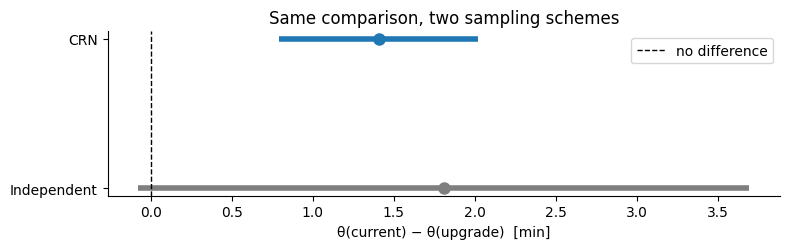

In [6]:
# Visualize the two CIs against 0
fig, ax = plt.subplots(figsize=(8, 2.6))
for k, (label, d, h, col) in enumerate([
        ('Independent', diff_ind, H_ind, D3_GRAY),
        ('CRN',         diff_crn, H_crn, D3_BLUE)]):
    ax.hlines(k, d-h, d+h, color=col, lw=4)
    ax.plot(d, k, 'o', color=col, ms=8)
ax.axvline(0, color='black', lw=1, ls='--', label='no difference')
ax.set_yticks([0, 1]); ax.set_yticklabels(['Independent', 'CRN'])
ax.set_xlabel('θ(current) − θ(upgrade)  [min]')
ax.set_title('Same comparison, two sampling schemes')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Sample size for a difference with CRN

Same logic as the single-mean case — but using $S_D$ from a pilot of $R_0$ paired replications. To get half-width $\le \varepsilon$:

$$R \ge \left(\frac{t_{\alpha/2,\,R_0-1}\cdot S_D}{\varepsilon}\right)^2$$

Because CRN makes $S_D$ small, the required $R$ is **far smaller** than for independent sampling — that is the whole point.

# 🧠 Mentimeter — your turn (Q3)

➡️ Open the Mentimeter and answer the question on screen.

# Part 3 — Comparing Several Systems

## The setup — non-ordered designs

Adding cashiers is **monotone** (more cashiers ⇒ shorter wait), so transitivity would spare us most comparisons. The interesting case is **qualitatively different designs with no a priori ordering** — e.g. *hire a second cashier* vs *upgrade the terminal* vs *use several slow cashiers*.

When the designs aren't on a single axis, we genuinely need to compare **all pairs**. Typical goals when there are $K$ designs:

1. **Individual CIs** — one CI per system ($C = K$ statements)
2. **Compare against a control** — each system vs the status quo ($C = K-1$)
3. **All pairwise comparisons** — every pair ($C = \binom{K}{2} = K(K-1)/2$)

The new danger: making **many comparisons** inflates the chance of *at least one* wrong conclusion.

## The multiplicity problem

Each 95% CI is wrong with probability 5%. Build 20 of them, and the expected number of "misses" is $20 \times 0.05 = 1$ — so seeing a false conclusion somewhere becomes *likely*, not rare.

The chance that **all** $C$ independent 95% CIs are simultaneously correct is only $0.95^{C}$:

| $C$ | $0.95^C$ (all correct) |
|---|---|
| 1 | 95% |
| 5 | 77% |
| 10 | 60% |
| 20 | 36% |

→ With 20 comparisons, you're *more likely than not* to draw at least one wrong conclusion. We need to control the **overall** error.

## The Bonferroni correction

**Bonferroni inequality:** if we make $C$ statements, each at error level $\alpha_j$, the probability that **all** hold simultaneously satisfies
$$P(\text{all } C \text{ statements correct}) \;\ge\; 1 - \sum_{j=1}^C \alpha_j \;=\; 1 - \alpha_E$$

where $\alpha_E$ is the **overall (experiment-wide) error**.

**Fix:** to guarantee overall confidence $1-\alpha_E$, split the budget — use $\alpha_j = \alpha_E / C$ for each individual comparison.

→ Each individual CI uses a *more extreme* critical value → each CI is **wider** — the price of making many comparisons safely.

## The four mensa designs we compare

| Design | Cashiers | Mean service | Idea |
|---|---|---|---|
| **A — status quo** | 1 | 1.5 min | the current setup, our baseline |
| **B — hire** | 2 | 1.5 min | add a second cashier |
| **C — faster POS** | 1 | 1.0 min | keep one cashier, upgrade the terminal so each transaction is faster |
| **D — three slow staff** | 3 | 3.0 min | three cheap/untrained cashiers, each markedly slower |

The trade-offs pull in different directions — more servers vs faster service — so the ranking of B, C, D is **not predictable in advance**. We must compare all pairs. The code below runs $R = 12$ replications per design and applies the Bonferroni-adjusted CI to every pair.

In [7]:
# Bonferroni in action: all-pairwise comparison of four non-ordered designs
designs = {
    'A status-quo':  dict(num_cashiers=1, mean_service=1.5),
    'B hire':        dict(num_cashiers=2, mean_service=1.5),
    'C faster-POS':  dict(num_cashiers=1, mean_service=1.0),
    'D three-slow':  dict(num_cashiers=3, mean_service=3.0),
}
R = 12
alpha_E = 0.05

# per-replication means for each design (independent samples)
samples = {name: np.array([mean_wait(s + 100*k, **cfg) for s in range(1, R+1)])
           for k, (name, cfg) in enumerate(designs.items())}

names = list(designs)
pairs = [(a, b) for i, a in enumerate(names) for b in names[i+1:]]
C = len(pairs)
alpha_j = alpha_E / C
print(f"K = {len(names)} designs → C = {C} pairwise comparisons")
print(f"Per-comparison level: alpha_j = {alpha_E}/{C} = {alpha_j:.4f}  "
      f"(per-comparison confidence {(1-alpha_j)*100:.1f}%)")
print()
print("mean wait per design:")
for name in names:
    print(f"   {name:14s}: {samples[name].mean():.2f} min")
print()

for a, b in pairs:
    xa, xb = samples[a], samples[b]
    d = xa.mean() - xb.mean()
    se = np.sqrt(xa.var(ddof=1)/R + xb.var(ddof=1)/R)
    nu = (xa.var(ddof=1)/R + xb.var(ddof=1)/R)**2 / (
         (xa.var(ddof=1)/R)**2/(R-1) + (xb.var(ddof=1)/R)**2/(R-1))
    H = stats.t.ppf(1 - alpha_j/2, nu) * se          # Bonferroni-adjusted
    if d - H > 0:
        verdict = f"{b} wins (lower wait)"
    elif d + H < 0:
        verdict = f"{a} wins (lower wait)"
    else:
        verdict = "inconclusive — tie"
    print(f"{a:14s} vs {b:14s}: diff = {d:6.2f}  CI [{d-H:6.2f}, {d+H:6.2f}]  → {verdict}")

K = 4 designs → C = 6 pairwise comparisons
Per-comparison level: alpha_j = 0.05/6 = 0.0083  (per-comparison confidence 99.2%)

mean wait per design:
   A status-quo  : 4.14 min
   B hire        : 0.25 min
   C faster-POS  : 1.10 min
   D three-slow  : 0.46 min

A status-quo   vs B hire        : diff =   3.89  CI [  1.83,   5.94]  → B hire wins (lower wait)
A status-quo   vs C faster-POS  : diff =   3.04  CI [  0.98,   5.11]  → C faster-POS wins (lower wait)
A status-quo   vs D three-slow  : diff =   3.68  CI [  1.62,   5.74]  → D three-slow wins (lower wait)
B hire         vs C faster-POS  : diff =  -0.85  CI [ -1.34,  -0.35]  → B hire wins (lower wait)
B hire         vs D three-slow  : diff =  -0.21  CI [ -0.64,   0.22]  → inconclusive — tie
C faster-POS   vs D three-slow  : diff =   0.64  CI [  0.08,   1.19]  → D three-slow wins (lower wait)


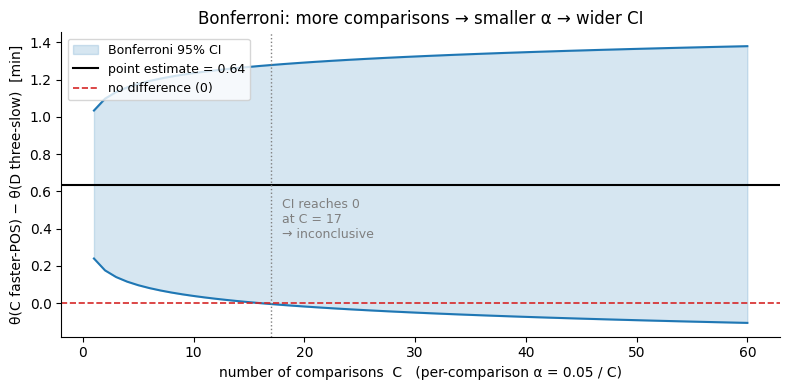

As C grows the per-comparison α = 0.05/C shrinks, t_{α/2,ν} grows, and the CI
widens. Here a genuine difference becomes inconclusive once we honestly
correct for ~17 comparisons — right at the practical Bonferroni limit.


In [8]:
# How one comparison's CI widens as the number of comparisons C grows
# (Bonferroni: alpha_j = alpha_E / C  → smaller alpha → wider CI)
# NOTE: this cell generates images/oa_bonferroni_ci_widening.png, shown on the next slide.
a, b = 'C faster-POS', 'D three-slow'
xa, xb = samples[a], samples[b]
d = xa.mean() - xb.mean()
se = np.sqrt(xa.var(ddof=1)/R + xb.var(ddof=1)/R)
nu = (xa.var(ddof=1)/R + xb.var(ddof=1)/R)**2 / (
     (xa.var(ddof=1)/R)**2/(R-1) + (xb.var(ddof=1)/R)**2/(R-1))

alpha_E = 0.05
Cs = np.arange(1, 61)
H = np.array([stats.t.ppf(1 - (alpha_E/C)/2, nu) * se for C in Cs])
lower = d - H
upper = d + H

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(Cs, lower, upper, alpha=0.18, color=D3_BLUE, label='Bonferroni 95% CI')
ax.plot(Cs, upper, color=D3_BLUE, lw=1.5)
ax.plot(Cs, lower, color=D3_BLUE, lw=1.5)
ax.axhline(d, color='black', lw=1.5, label=f'point estimate = {d:.2f}')
ax.axhline(0, color=D3_RED, lw=1.2, ls='--', label='no difference (0)')

# mark the C at which the CI first reaches 0 (verdict flips to inconclusive)
flip = Cs[lower <= 0]
if len(flip):
    Cflip = flip[0]
    ax.axvline(Cflip, color=D3_GRAY, ls=':', lw=1)
    ax.text(Cflip + 1, d*0.55, f'CI reaches 0\nat C = {Cflip}\n→ inconclusive', fontsize=9, color=D3_GRAY)

ax.set_xlabel('number of comparisons  C   (per-comparison α = 0.05 / C)')
ax.set_ylabel(f'θ({a}) − θ({b})  [min]')
ax.set_title('Bonferroni: more comparisons → smaller α → wider CI')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('images/oa_bonferroni_ci_widening.png', dpi=130, bbox_inches='tight')
plt.show()

print("As C grows the per-comparison α = 0.05/C shrinks, t_{α/2,ν} grows, and the CI")
print("widens. Here a genuine difference becomes inconclusive once we honestly")
print("correct for ~17 comparisons — right at the practical Bonferroni limit.")

## Bonferroni in action — how one CI widens with $C$

The same comparison **C faster-POS vs D three-slow**, redrawn at every Bonferroni level $\alpha_j = 0.05/C$:

<img src="images/oa_bonferroni_ci_widening.png" style="width:62%; float:center;" />

As $C$ grows the per-comparison $\alpha = 0.05/C$ shrinks, $t_{\alpha/2,\nu}$ grows, and the CI **widens**. A genuine difference becomes **inconclusive** once we honestly correct for ~17 comparisons — right at the practical Bonferroni limit.

## Number of comparisons by goal

| Goal | Statements $C$ | Example ($K=4$) |
|---|---|---|
| Individual CI per system | $K$ | 4 |
| Each vs a control | $K-1$ | 3 |
| All pairwise | $K(K-1)/2$ | 6 |

Because the CIs widen with $C$, Bonferroni is practical only up to roughly **$C \le 20$**. Beyond that, the correction makes every CI uselessly wide — we need a smarter method.

## Selecting the best — the indifference-zone idea

For **large** $K$ (tens to hundreds of designs), all-pairwise CIs are hopeless. Instead we ask a more modest question, controlled by an **indifference zone** $\varepsilon$:

> "Return a system whose true mean is within $\varepsilon$ of the best, with probability $\ge 1-\alpha$."

The $\varepsilon$ is what makes the problem tractable: we *do not care* about differences smaller than $\varepsilon$ (practical significance again), so we never have to resolve them — that would cost enormous sample sizes. We only need enough data to reliably separate systems that differ by **more** than $\varepsilon$.

## The two-stage selection procedure (Banks et al., Ch. 12)

Goal: select the system with the smallest mean, with a **probability of correct selection (PCS)** $\ge 1-\alpha$ whenever the best leads by at least $\varepsilon$. Split the budget $\alpha = \alpha_1 + \alpha_2$.

**Stage 1 — screening (level $\alpha_1$).** Run $n_0$ pilot replications per system; **screen out** every system that is statistically worse than a competitor. *If only one survives, stop.*

**Stage 2 — selection (level $\alpha_2$).** For the survivors, run **more replications** (more for higher-variance systems), then **select the one with the smallest mean**.

> **Guarantee:** with probability $\ge 1-\alpha$ the chosen system is within $\varepsilon$ of the true best.

*Exact widths and Rinott's constant: Banks et al. (2013), p. 476ff. (NSGS procedure).*

# 🧠 Mentimeter — your turn (Q4)

➡️ Open the Mentimeter and answer the question on screen.

# Part 4 — Metamodeling

## The idea

Each simulation run is **expensive**. If we want to know the mean wait for *many* settings of an input (arrival rate, service rate, …), running a full simulation at every setting is wasteful.

**Metamodel:** run the simulation at a handful of design points, then fit a **cheap function** $\hat Y = f(x)$ that approximates the simulation's response. Evaluate the function — not the simulation — everywhere else.

<img src="images/oa_metamodel_linear.png" style="width:52%; float:center;" />

The simulation is the "truth"; the metamodel is a fast **approximation of the truth**.

## Simple linear regression — the basic metamodel

Model the simulation response $Y$ as a linear function of one input $x$:
$$Y = \beta_0 + \beta_1 x + \varepsilon, \qquad \varepsilon \sim (\text{mean }0,\ \text{variance }\sigma^2)$$

Fit by **least squares** — minimise the sum of squared residuals $\sum_i (Y_i - \beta_0 - \beta_1 x_i)^2$. The solution (you know this from statistics):
$$\hat\beta_1 = \frac{S_{xy}}{S_{xx}} = \frac{\sum_i (x_i-\bar x)(Y_i-\bar Y)}{\sum_i (x_i-\bar x)^2}, \qquad \hat\beta_0 = \bar Y - \hat\beta_1 \bar x$$

*(Full derivation from $\partial L/\partial\beta = 0$ in the appendix.)*

## Mensa metamodel — wait vs arrival rate

In [9]:
# Run the simulation at a few design points; summarise each by its mean wait.
# A metamodel is fitted on the design-point summaries (one (x, Ȳ) per setting).
inter_arrivals = [2.8, 2.6, 2.4, 2.2, 2.0]     # design points (min between arrivals)
R = 20
rates, point_means, point_clouds = [], [], []
for mi in inter_arrivals:
    runs = np.array([mean_wait(s + int(mi*100), num_cashiers=1, mean_inter=mi)
                     for s in range(1, R+1)])
    rates.append(1/mi)                           # arrival RATE (per min)
    point_means.append(runs.mean())
    point_clouds.append(runs)
rates = np.array(rates); point_means = np.array(point_means)

# Least-squares fit on the design-point means
slope, intercept, r_value, p_value, std_err = stats.linregress(rates, point_means)
print(f"Metamodel: mean_wait ≈ {intercept:.2f} + {slope:.2f} · (arrival rate)")
print(f"R² = {r_value**2:.3f},  slope p-value = {p_value:.2e}")

Metamodel: mean_wait ≈ -3.67 + 14.82 · (arrival rate)
R² = 0.883,  slope p-value = 1.77e-02


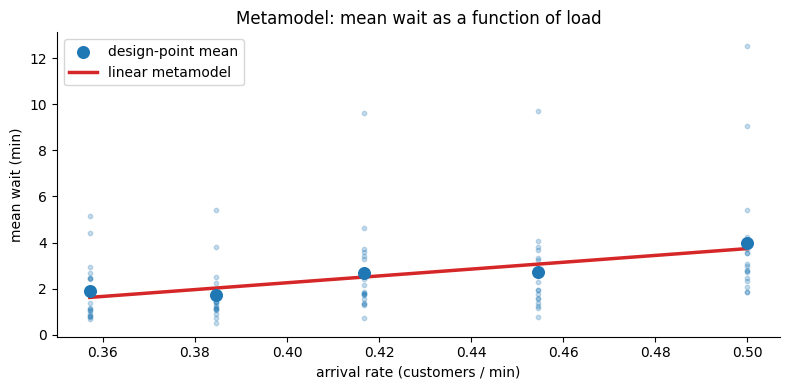

In [10]:
# Plot the fitted metamodel over the design-point means (with the run cloud behind)
fig, ax = plt.subplots(figsize=(8, 4))
for rate, cloud in zip(rates, point_clouds):
    ax.scatter(np.full_like(cloud, rate), cloud, s=10, color=D3_BLUE, alpha=0.25)
ax.scatter(rates, point_means, s=70, color=D3_BLUE, zorder=3, label='design-point mean')
xg = np.linspace(rates.min(), rates.max(), 100)
ax.plot(xg, intercept + slope*xg, color=D3_RED, lw=2.5, label='linear metamodel')
ax.set_xlabel('arrival rate (customers / min)')
ax.set_ylabel('mean wait (min)')
ax.set_title('Metamodel: mean wait as a function of load')
ax.legend()
plt.tight_layout()
plt.savefig('images/oa_metamodel_linear.png', dpi=130, bbox_inches='tight')
plt.show()

## Is the fit any good? — significance & diagnostics

Two checks (from your statistics toolbox — we only recall them here):

- **Slope significance:** test $H_0: \beta_1 = 0$ with $t_0 = \hat\beta_1 / \text{s.e.}(\hat\beta_1)$; small $p$-value → $x$ genuinely drives $Y$.
- **$R^2$** — fraction of variance explained: $R^2 = 1 - SS_E/SS_T$.
- **Residual plot** — residuals should look like structureless noise around 0 (✓ here). A **systematic curve** (e.g. a U-shape) would signal that a straight line is too simple → add a **quadratic** term.

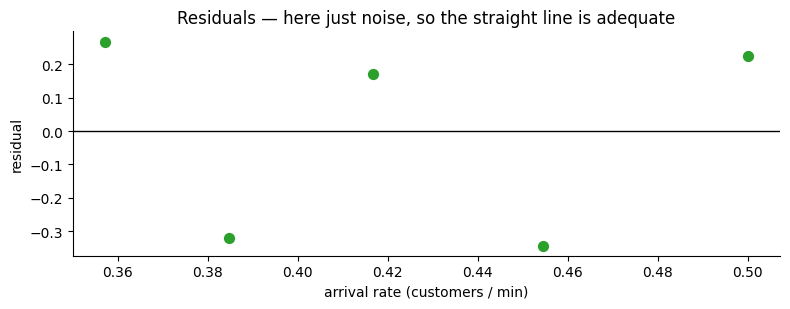

In [11]:
# Residual diagnostic — does a straight line suffice?
resid = point_means - (intercept + slope*rates)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.scatter(rates, resid, s=50, color=D3_GREEN)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('arrival rate (customers / min)')
ax.set_ylabel('residual')
ax.set_title('Residuals — here just noise, so the straight line is adequate')
plt.tight_layout()
plt.show()

**No systematic pattern.** The residuals alternate in sign and are about the size of the replication noise (~±0.3 min) — so the linear metamodel is **adequate over this load range**.

The known **convexity** of queueing delay would only show up over a much wider range, as utilisation approaches 1 — *then* a residual U-shape would appear and call for a quadratic term.

## Multiple linear regression — more inputs, richer shapes

With several inputs (and non-linear effects), extend the metamodel:

$$\text{linear: } Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon$$
$$\text{quadratic: } Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \varepsilon$$
$$\text{interaction: } Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \varepsilon$$

Choose between candidate metamodels with **adjusted $R^2$**, **MSE**, or **AIC** — all of which penalise needless complexity. (Use CRN across design points to make the fitted surface smoother — see appendix.)

# Part 5 — Optimization via Simulation

## From "compare a few" to "search over many"

Bonferroni handles a handful of designs; ranking & selection handles dozens. But what if the design space is **huge** — every combination of cashiers, opening hours, queue policy?

**Optimization via simulation:** treat the simulation as a black-box objective $Y(\mathbf{x})$ over decision variables $\mathbf{x}$, and let a **search heuristic** propose which designs to evaluate next.

```
    propose x  →  simulate Y(x)  →  heuristic updates  →  propose next x  →  …
                        ↑______________________________________|
```

## How it works in practice

- **Decision variables** $\mathbf{x}$: e.g. number of cashiers, staff schedule, buffer sizes.
- **Objective** $Y(\mathbf{x})$: a simulation output (mean wait, cost, throughput) — possibly an aggregate.
- **Search heuristic:** metaheuristics like **genetic algorithms** or **tabu search** propose new candidates, balancing exploration and exploitation.
- **Stopping:** time budget, or negligible improvement over recent iterations.

## The catch — stochastic output has no guarantees

The objective is **noisy**: $Y(\mathbf{x})$ differs run to run. Two consequences:

1. **A design may look best by luck.** Always estimate $Y(\mathbf{x})$ with enough replications (or CRN across candidates) so the *ranking* is trustworthy — not just a single noisy run.
2. **No optimality certificate.** Unlike deterministic optimization, you cannot prove you found the global optimum. **Restart** the search from different seeds and starting points and keep the best.

→ Optimization-via-simulation is *everything from this lecture, automated*: each candidate evaluation is an output-analysis problem; comparing candidates is a multiple-systems problem.

## Where it's used in practice

Optimization via simulation is the workhorse whenever the objective can only be *evaluated by running a stochastic model*, not written in closed form:

- **Staffing & scheduling** — call-centre shift rosters, nurse schedules, cashier allocation across the day
- **Inventory & supply chains** — reorder points and order quantities that minimise expected holding + stock-out cost
- **Manufacturing** — buffer sizes, line balancing, maintenance intervals
- **Logistics & networks** — vehicle fleet sizing, warehouse layout, traffic-signal timing
- **Healthcare** — emergency-department capacity, operating-room scheduling, ambulance base locations
- **Finance** — portfolio rules evaluated by Monte-Carlo scenarios

In each case the design space is far too large to enumerate, the objective is noisy, and a search heuristic proposes which configurations to simulate next.

# Part 6 — Closing

## Which method when? — scaling with the number of designs

| # of designs | Method | Tool |
|---|---|---|
| **2** | CI for the difference (+ CRN) | unequal-variances $t$-CI on $\bar Y_1 - \bar Y_2$ or paired $\bar D$ |
| **a few (≤ ~20)** | All-pairwise / vs-control with multiplicity control | Bonferroni-adjusted CIs |
| **dozens** | Select the best within $\varepsilon$ | Ranking & selection (indifference zone) |
| **many / continuous** | Search the design space | Metamodeling + optimization via simulation |

Each step **builds on the previous** — and all of them rest on the single-model output analysis from last lecture.

## What we learned

1. **Compare the difference, not the two means separately** — and read the difference-CI against 0.
2. **Statistical ≠ practical significance** — report the CI *and* the practical threshold.
3. **CRN reduces variance for free** — induce positive correlation, then difference it away. Same covariance algebra that hurt us with autocorrelation, now working for us.
4. **Many comparisons inflate error** — Bonferroni splits the $\alpha$ budget; ranking & selection scales further.
5. **Metamodels** replace expensive simulation with a cheap fitted function; **optimization** automates the search.

## Next session

We've now covered the full simulation pipeline: modeling, input data, V&V, and output analysis of one and many systems.

**What's next:** putting it all together in your own simulation study — see the **bonus project**.

# Appendix

## A.2 — Why CRN needs positive correlation (and synchronization gives it)

The difference variance is
$$\mathrm{Var}(\bar Y_{\cdot 1} - \bar Y_{\cdot 2}) = \frac{\sigma_1^2 + \sigma_2^2 - 2\rho_{12}\sigma_1\sigma_2}{R}.$$

Reduction vs independent sampling happens iff $\rho_{12} > 0$. Synchronization creates $\rho_{12} > 0$ because the **same** arrival/service shocks push *both* systems' waits in the **same** direction — when system 1 has a bad day, so does system 2, so their difference stays stable.

If synchronization breaks (streams misalign), $\rho_{12} \to 0$ and CRN degenerates to independent sampling. Worse: a *negative* $\rho_{12}$ (possible with a non-monotone response) would *increase* the variance.

## A.1 — Proof of the Bonferroni inequality

**Claim.** If we make $C$ statements $S_1, \ldots, S_C$, each a CI with individual error probability $\alpha_j$ (i.e. $P(S_j \text{ wrong}) = \alpha_j$), then
$$P(\text{all } C \text{ statements correct}) \;\ge\; 1 - \sum_{j=1}^C \alpha_j.$$

**Proof.** Let $E_j$ be the event "statement $j$ is **wrong**", with $P(E_j) = \alpha_j$. "At least one statement is wrong" is the union $E_1 \cup \cdots \cup E_C$.

By the **union bound** (Boole's inequality) — the probability of a union never exceeds the sum of the probabilities, *regardless of any dependence between the events*:
$$P\!\left(\bigcup_{j=1}^C E_j\right) \;\le\; \sum_{j=1}^C P(E_j) \;=\; \sum_{j=1}^C \alpha_j.$$

Taking complements ("all statements correct" is the complement of "at least one wrong"):
$$P\!\left(\bigcap_{j=1}^C E_j^{\,c}\right) = 1 - P\!\left(\bigcup_{j=1}^C E_j\right) \;\ge\; 1 - \sum_{j=1}^C \alpha_j. \qquad\blacksquare$$

**Why the union bound holds.** For two events, $P(A \cup B) = P(A) + P(B) - P(A\cap B) \le P(A) + P(B)$ since $P(A\cap B) \ge 0$. Induction extends this to $C$ events.

**Consequences.**
- Setting each $\alpha_j = \alpha_E / C$ gives overall error $\le \alpha_E$ — the correction we use.
- The bound needs **no independence assumption** — that is its strength (it always holds) and its weakness (it is *conservative*: when the tests are positively dependent the true family-wise error is smaller, so the CIs are wider than strictly necessary).

## A.3 — References

- **Banks, Carson, Nelson & Nicol (2013).** *Discrete-Event System Simulation.* Pearson. — Two-system comparison & CRN (Ch. 12.1–12.2), Bonferroni & ranking-and-selection (Ch. 12.3), metamodeling (Ch. 12.4), optimization (Ch. 12.5).
- **Güneş (2012).** *Modeling and Performance Analysis with Simulation.* FU Berlin.
- **Friedman, A. M. (2022).** *Introduction to Simulation Modeling and Analysis.* CUNY. https://sim.proffriedman.net